# S&P 500 · Gold · Fed Rate — Weekly Analysis
Downloads weekly data from Yahoo Finance (S&P 500, Gold) and FRED (Fed Funds Rate),
then plots a dual-axis chart with period bands and computes Pearson correlation tables.

**Periods**
- Bubble: Jan 2000 – Dec 2009
- QE ∞: Jan 2010 – Dec 2022
- Dollar Weaponization: Jan 2023 – present (Russia reserve freeze triggered central bank gold buying)

In [ ]:
# Install dependencies (run once)
!pip install yfinance pandas-datareader matplotlib scipy numpy plotly --quiet

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.dates import YearLocator, DateFormatter
import pandas_datareader.data as web
from scipy.stats import pearsonr
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 140,
})

print('Libraries loaded.')

Libraries loaded.


In [3]:
# ── CONFIG ────────────────────────────────────────────────────────────────────
START = '2000-01-01'
END   = datetime.today().strftime('%Y-%m-%d')

PERIODS = {
    'Bubble\n2000–2009':             ('2000-01-01', '2009-12-31', '#BA7517', 0.10),
    'QE ∞\n2010–2022':              ('2010-01-01', '2022-12-31', '#185FA5', 0.09),
    'Dollar Weaponization\n2023–':   ('2023-01-01', END,          '#7F77DD', 0.11),
}

CORR_PERIODS = {
    'Bubble (2000–2009)':                  ('2000-01-01', '2009-12-31'),
    'QE ∞ (2010–2022)':                   ('2010-01-01', '2022-12-31'),
    f'Dollar Weaponization (2023–{END[:7]})': ('2023-01-01', END),
}

In [ ]:
# ── DOWNLOAD DATA ─────────────────────────────────────────────────────────────
# Download daily then resample to W-FRI so SP500 / Gold / IRX share the same dates.
# Yahoo Finance weekly bars use different day-of-week labels per ticker,
# causing zero-overlap on concat and 50% spurious zero-returns.

def _to_weekly(raw, name):
    s = raw['Close'].squeeze()
    s.index = pd.to_datetime(s.index).tz_localize(None)
    return s.resample('W-FRI').last().rename(name)

print('Downloading S&P 500 (Yahoo Finance)...')
sp500 = _to_weekly(yf.download('^GSPC', start=START, end=END, interval='1d', progress=False), 'SP500')

print('Downloading Gold futures GC=F (Yahoo Finance)...')
gold  = _to_weekly(yf.download('GC=F',  start=START, end=END, interval='1d', progress=False), 'Gold')

# ^IRX = 13-week T-bill yield — closely tracks Fed Funds Rate
print('Downloading 13-week T-bill rate ^IRX (Yahoo Finance, proxy for Fed Funds Rate)...')
fed_weekly = _to_weekly(yf.download('^IRX', start=START, end=END, interval='1d', progress=False), 'FedRate').to_frame()

# ── MERGE & CLEAN ─────────────────────────────────────────────────────────────
df = pd.concat([sp500, gold, fed_weekly], axis=1)
df.ffill(inplace=True)
df.dropna(inplace=True)

print(f'\nMerged dataset: {len(df):,} weekly rows')
print(f'Date range   : {df.index[0].date()}  to  {df.index[-1].date()}')
df.tail(3)

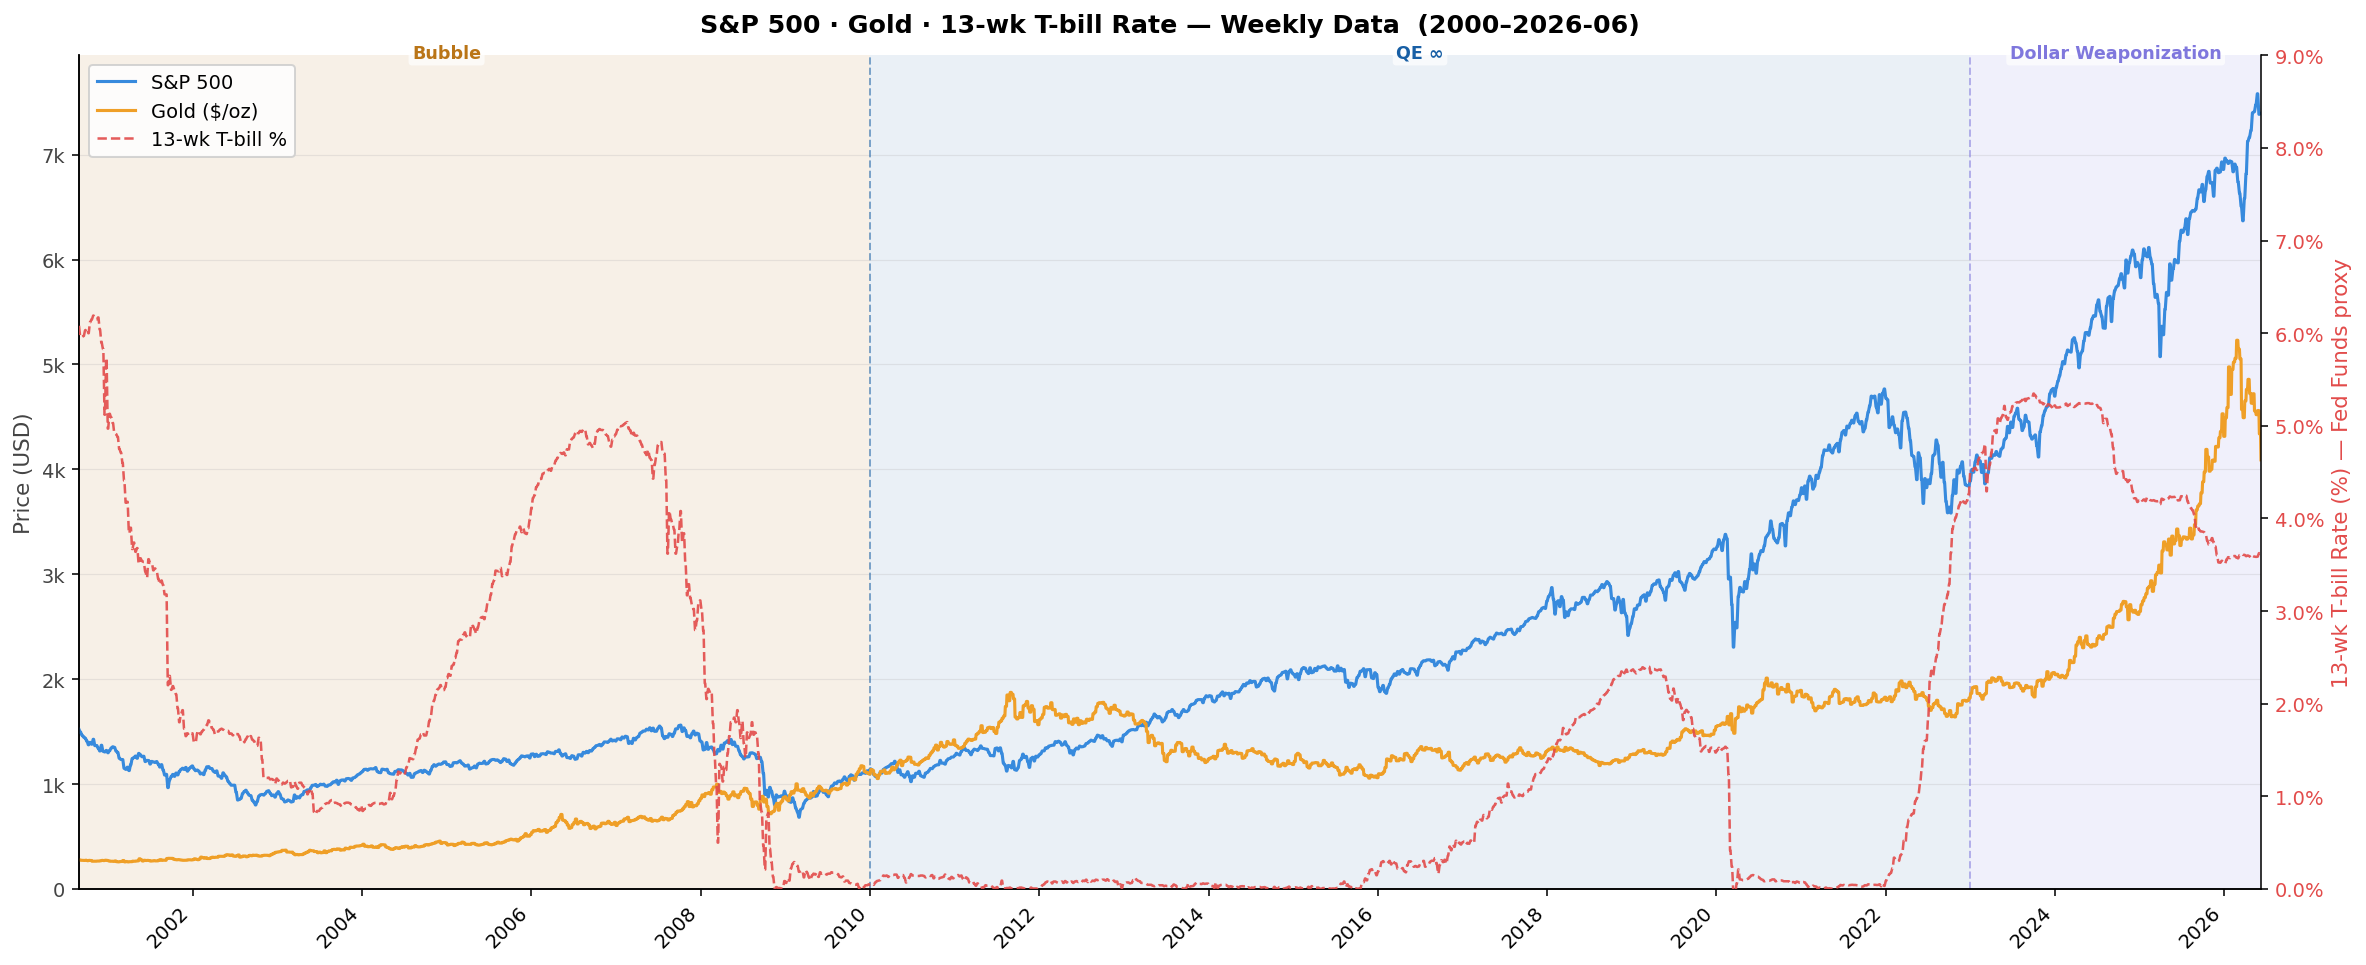

Chart saved → chart_weekly.png


In [5]:
# ── CHART ─────────────────────────────────────────────────────────────────────
SP_COLOR   = '#378ADD'
GOLD_COLOR = '#EF9F27'
FED_COLOR  = '#E24B4A'

fig, ax1 = plt.subplots(figsize=(17, 7))
ax2 = ax1.twinx()

# ── Period shading ────────────────────────────────────────────────────────────
for label, (p_start, p_end, color, alpha) in PERIODS.items():
    s = pd.Timestamp(p_start)
    e = min(pd.Timestamp(p_end), df.index[-1])
    ax1.axvspan(s, e, alpha=alpha, color=color, zorder=1, linewidth=0)
    ax1.axvline(s, color=color, linewidth=1.0, linestyle='--', alpha=0.55, zorder=2)
    mid = s + (e - s) / 2
    short_label = label.split('\n')[0]          # just the first line for the band
    ax1.text(
        mid, df['SP500'].max() * 1.04,
        short_label, ha='center', va='bottom',
        fontsize=9, fontweight='bold', color=color,
        bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.7)
    )

# ── Lines ─────────────────────────────────────────────────────────────────────
ax1.plot(df.index, df['SP500'], color=SP_COLOR,   linewidth=1.6, label='S&P 500',    zorder=4)
ax1.plot(df.index, df['Gold'],  color=GOLD_COLOR, linewidth=1.6, label='Gold ($/oz)', zorder=4)
ax2.plot(df.index, df['FedRate'], color=FED_COLOR, linewidth=1.3,
         linestyle='--', label='13-wk T-bill %', zorder=4, alpha=0.9)

# ── Axes formatting ───────────────────────────────────────────────────────────
ax1.set_ylim(bottom=0)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k' if x >= 1000 else str(int(x))))
ax1.set_ylabel('Price (USD)', fontsize=11, color='#444')
ax1.tick_params(axis='y', labelcolor='#444')

ax2.set_ylim(0, 9)
ax2.set_ylabel('13-wk T-bill Rate (%) — Fed Funds proxy', fontsize=11, color=FED_COLOR)
ax2.tick_params(axis='y', labelcolor=FED_COLOR)
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
ax2.spines['right'].set_visible(True)

ax1.xaxis.set_major_locator(YearLocator(2))
ax1.xaxis.set_major_formatter(DateFormatter('%Y'))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')
ax1.set_xlim(df.index[0], df.index[-1])

# ── Legend ────────────────────────────────────────────────────────────────────
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='upper left', fontsize=10, framealpha=0.85)

ax1.set_title(
    f'S&P 500 · Gold · 13-wk T-bill Rate — Weekly Data  ({START[:4]}–{END[:7]})',
    fontsize=13, fontweight='bold', pad=12
)
ax1.set_xlabel('', fontsize=11)
ax1.grid(axis='y', alpha=0.25, linewidth=0.6)

plt.tight_layout()
plt.savefig('chart_weekly.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved → chart_weekly.png')

In [ ]:
# ── WEEKLY RETURNS ────────────────────────────────────────────────────────────
# Prices: pct_change().  FedRate: diff() (absolute %-pt change).
# pct_change() on near-zero yields (2010-2015) produces extreme noise and kills correlations.
returns = pd.DataFrame({
    'SP500':   df['SP500'].pct_change(),
    'Gold':    df['Gold'].pct_change(),
    'FedRate': df['FedRate'].diff(),
}).dropna()
print(f'Weekly return rows: {len(returns):,}')
returns.describe().round(4)

In [7]:
# ── CORRELATION TABLE ─────────────────────────────────────────────────────────
PAIRS = [
    ('FedRate', 'Gold',   'Fed ↔ Gold'),
    ('FedRate', 'SP500',  'Fed ↔ S&P 500'),
    ('Gold',    'SP500',  'Gold ↔ S&P 500'),
]

def period_corr(rets, start, end):
    mask = (rets.index >= pd.Timestamp(start)) & (rets.index <= pd.Timestamp(end))
    r = rets[mask]
    rows = []
    for col_a, col_b, label in PAIRS:
        valid = r[[col_a, col_b]].dropna()
        n = len(valid)
        if n > 10:
            corr, pval = pearsonr(valid[col_a], valid[col_b])
            stars = '***' if pval < 0.001 else ('**' if pval < 0.01 else ('*' if pval < 0.05 else ''))
            rows.append({'Pair': label, 'Correlation': round(corr, 3),
                         'p-value': round(pval, 4), 'Sig': stars, 'n (weeks)': n})
        else:
            rows.append({'Pair': label, 'Correlation': None,
                         'p-value': None, 'Sig': 'n/a', 'n (weeks)': n})
    return pd.DataFrame(rows).set_index('Pair')


# Pretty-print each period
for period_name, (start, end) in CORR_PERIODS.items():
    tbl = period_corr(returns, start, end)
    print(f'\n{'='*60}')
    print(f'  {period_name}')
    print(f'{'='*60}')
    print(tbl.to_string())

print('\n* p<0.05  ** p<0.01  *** p<0.001')


  Bubble (2000–2009)
                Correlation  p-value  Sig  n (weeks)
Pair                                                
Fed ↔ Gold           -0.003   0.9259             974
Fed ↔ S&P 500         0.164   0.0000  ***        974
Gold ↔ S&P 500        0.001   0.9852             974

  QE ∞ (2010–2022)
                Correlation  p-value Sig  n (weeks)
Pair                                               
Fed ↔ Gold           -0.003   0.9084           1357
Fed ↔ S&P 500         0.063   0.0210   *       1357
Gold ↔ S&P 500       -0.002   0.9392           1357

  Dollar Weaponization (2023–2026-06)
                Correlation  p-value Sig  n (weeks)
Pair                                               
Fed ↔ Gold            0.008   0.8809            359
Fed ↔ S&P 500        -0.046   0.3819            359
Gold ↔ S&P 500       -0.018   0.7316            359

* p<0.05  ** p<0.01  *** p<0.001


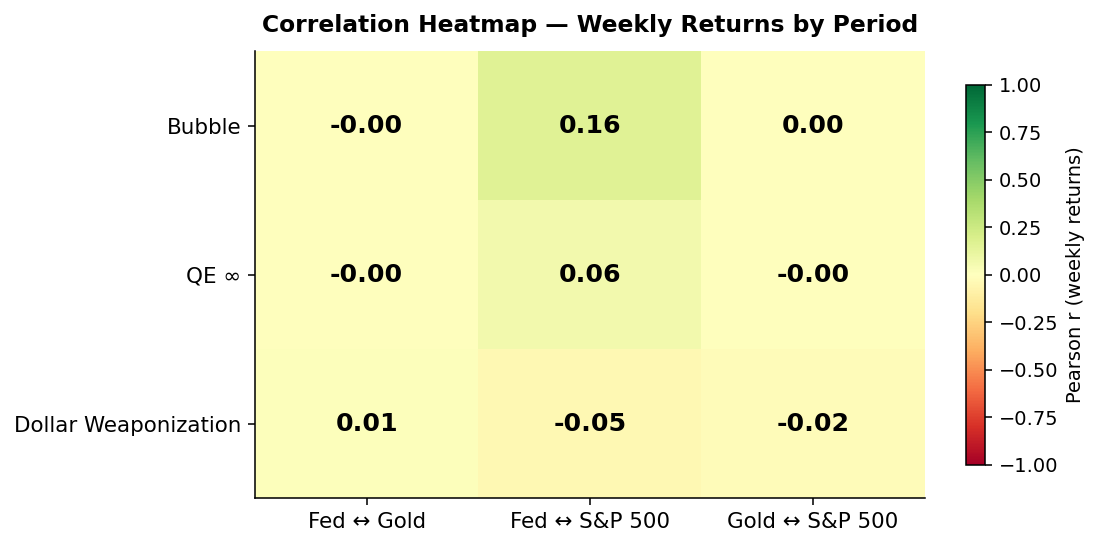

Heatmap saved → correlation_heatmap.png


In [8]:
# ── CORRELATION HEATMAP ───────────────────────────────────────────────────────
period_labels  = list(CORR_PERIODS.keys())
pair_labels    = [p[2] for p in PAIRS]
n_periods      = len(period_labels)
n_pairs        = len(pair_labels)

corr_matrix = np.zeros((n_periods, n_pairs))
for i, (pname, (start, end)) in enumerate(CORR_PERIODS.items()):
    tbl = period_corr(returns, start, end)
    for j, pair in enumerate(pair_labels):
        v = tbl.loc[pair, 'Correlation']
        corr_matrix[i, j] = v if v is not None else 0

fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(corr_matrix, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')

# Labels
ax.set_xticks(range(n_pairs))
ax.set_xticklabels(pair_labels, fontsize=11)
ax.set_yticks(range(n_periods))
ax.set_yticklabels([p.split('(')[0].strip() for p in period_labels], fontsize=11)

# Value annotations
for i in range(n_periods):
    for j in range(n_pairs):
        v = corr_matrix[i, j]
        color = 'white' if abs(v) > 0.5 else 'black'
        ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                fontsize=13, fontweight='bold', color=color)

plt.colorbar(im, ax=ax, label='Pearson r (weekly returns)', shrink=0.85)
ax.set_title('Correlation Heatmap — Weekly Returns by Period', fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Heatmap saved → correlation_heatmap.png')

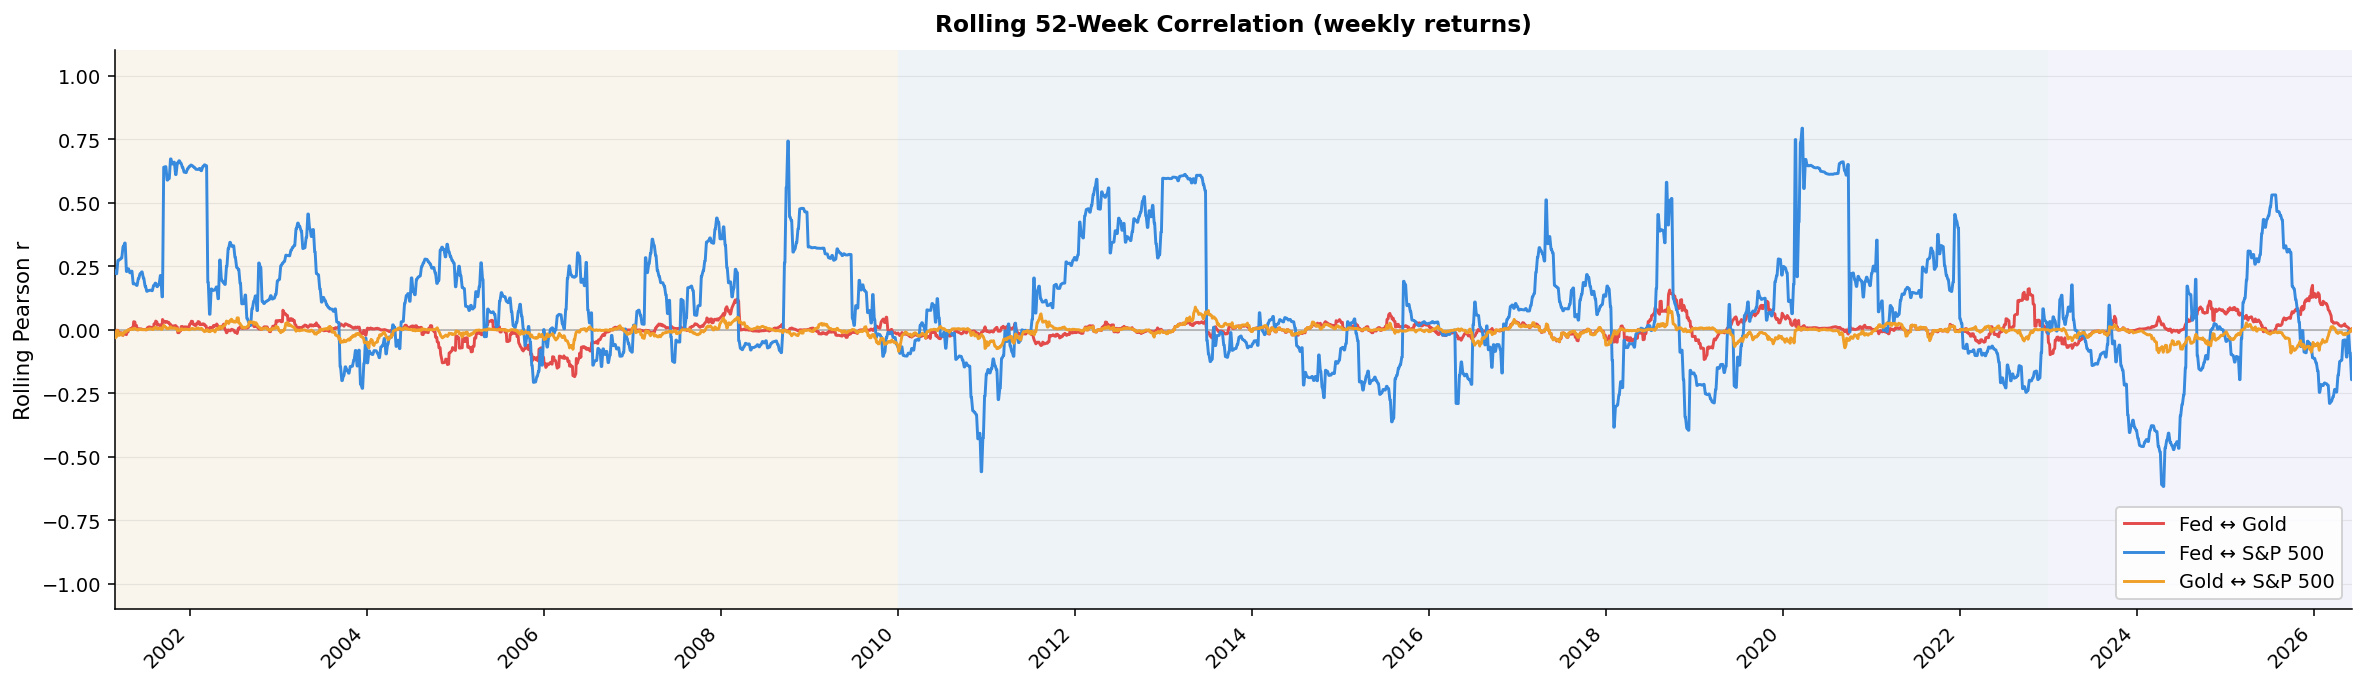

Rolling correlation chart saved → rolling_correlation.png


In [9]:
# ── ROLLING 52-WEEK CORRELATION ───────────────────────────────────────────────
# Useful for seeing how relationships shift over time
WINDOW = 52   # ~1 year of weekly data

roll_fg = returns['FedRate'].rolling(WINDOW).corr(returns['Gold'])
roll_fs = returns['FedRate'].rolling(WINDOW).corr(returns['SP500'])
roll_gs = returns['Gold'].rolling(WINDOW).corr(returns['SP500'])

fig, ax = plt.subplots(figsize=(17, 5))

# Period bands
for label, (p_start, p_end, color, alpha) in PERIODS.items():
    s = pd.Timestamp(p_start)
    e = min(pd.Timestamp(p_end), df.index[-1])
    ax.axvspan(s, e, alpha=alpha * 0.8, color=color, zorder=1, linewidth=0)

ax.axhline(0, color='#aaa', linewidth=0.8, linestyle='-')
ax.plot(roll_fg.index, roll_fg, color='#E24B4A', linewidth=1.5, label='Fed ↔ Gold',    zorder=3)
ax.plot(roll_fs.index, roll_fs, color='#378ADD', linewidth=1.5, label='Fed ↔ S&P 500', zorder=3)
ax.plot(roll_gs.index, roll_gs, color='#EF9F27', linewidth=1.5, label='Gold ↔ S&P 500', zorder=3)

ax.set_ylim(-1.1, 1.1)
ax.set_xlim(df.index[WINDOW], df.index[-1])
ax.xaxis.set_major_locator(YearLocator(2))
ax.xaxis.set_major_formatter(DateFormatter('%Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
ax.set_ylabel('Rolling Pearson r', fontsize=11)
ax.set_title(f'Rolling {WINDOW}-Week Correlation (weekly returns)', fontsize=12, fontweight='bold', pad=10)
ax.legend(loc='lower right', fontsize=10, framealpha=0.85)
ax.grid(axis='y', alpha=0.25, linewidth=0.6)

plt.tight_layout()
plt.savefig('rolling_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Rolling correlation chart saved → rolling_correlation.png')

In [ ]:
# ── INTERACTIVE HTML DASHBOARD ────────────────────────────────────────────────
import os

try:
    import plotly
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'plotly', '--quiet'], check=True)

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio

# ── Palette / style constants ──────────────────────────────────────────────────
_DARK_BG = '#0f0f1a'
_CARD_BG = '#141428'
_PLOT_BG = '#1a1a2e'
_TEXT    = '#c0c8e0'
_GRID    = 'rgba(255,255,255,0.08)'
_ZERO    = 'rgba(255,255,255,0.18)'
SP_C     = '#378ADD'
GOLD_C   = '#EF9F27'
FED_C    = '#E24B4A'

_PERIODS = [
    ('2000-01-01', '2009-12-31', '#BA7517', 0.10, 'Bubble<br>2000–2009'),
    ('2010-01-01', '2022-12-31', '#185FA5', 0.09, 'QE ∞<br>2010–2022'),
    ('2023-01-01', END,          '#7F77DD', 0.11, 'Dollar<br>Weaponization'),
]

# ── Chart 1 : Price + Rate time series ────────────────────────────────────────
f1 = make_subplots(specs=[[{"secondary_y": True}]])

for p0, p1, col, alpha, lbl in _PERIODS:
    s = pd.Timestamp(p0)
    e = min(pd.Timestamp(p1), df.index[-1])
    f1.add_vrect(x0=s, x1=e, fillcolor=col, opacity=alpha,
                 layer='below', line_width=0)
    f1.add_annotation(
        x=s + (e - s) / 2, y=1.05, yref='paper',
        text=lbl, showarrow=False, xanchor='center',
        font=dict(size=10, color=col),
        bgcolor='rgba(20,20,40,0.75)', borderpad=3,
    )

f1.add_trace(go.Scatter(
    x=df.index, y=df['SP500'], name='S&P 500',
    line=dict(color=SP_C, width=2),
    hovertemplate='S&P 500: $%{y:,.0f}<extra></extra>',
), secondary_y=False)

f1.add_trace(go.Scatter(
    x=df.index, y=df['Gold'], name='Gold ($/oz)',
    line=dict(color=GOLD_C, width=2),
    hovertemplate='Gold: $%{y:,.0f}<extra></extra>',
), secondary_y=False)

f1.add_trace(go.Scatter(
    x=df.index, y=df['FedRate'], name='13-wk T-bill %',
    line=dict(color=FED_C, width=1.5, dash='dash'),
    hovertemplate='Rate: %{y:.2f}%<extra></extra>',
), secondary_y=True)

f1.update_layout(
    title=dict(
        text=f'S&P 500 · Gold · 13-wk T-bill Rate — Weekly ({START[:4]}–{END[:7]})',
        font=dict(size=14, color=_TEXT),
    ),
    hovermode='x unified',
    height=520,
    paper_bgcolor=_CARD_BG,
    plot_bgcolor=_PLOT_BG,
    font=dict(color=_TEXT),
    legend=dict(orientation='h', yanchor='bottom', y=1.09,
                xanchor='right', x=1, bgcolor='rgba(20,20,40,0.85)'),
    margin=dict(t=115, b=50, l=75, r=90),
)
f1.update_yaxes(title_text='Price (USD)', secondary_y=False,
                tickformat='$,.0f', gridcolor=_GRID, zerolinecolor=_ZERO)
f1.update_yaxes(title_text='Rate (%)', secondary_y=True,
                range=[0, 9], tickformat='.1f', ticksuffix='%', showgrid=False)
f1.update_xaxes(showgrid=True, gridcolor=_GRID)

# ── Chart 2 : Correlation heatmap ─────────────────────────────────────────────
_ylabels = [p.split('(')[0].strip() for p in period_labels]

f2 = go.Figure(data=go.Heatmap(
    z=corr_matrix,
    x=pair_labels,
    y=_ylabels,
    colorscale='RdYlGn',
    zmin=-1, zmax=1,
    text=[[f'{v:.2f}' for v in row] for row in corr_matrix],
    texttemplate='<b>%{text}</b>',
    textfont=dict(size=15, color='#111111'),
    colorbar=dict(title='Pearson r',
                  tickfont=dict(color=_TEXT), titlefont=dict(color=_TEXT)),
    hovertemplate='<b>%{y}</b><br>%{x}<br>r = %{z:.3f}<extra></extra>',
))
f2.update_layout(
    title=dict(text='Correlation Heatmap — Weekly Returns by Period',
               font=dict(size=13, color=_TEXT)),
    height=380,
    paper_bgcolor=_CARD_BG,
    plot_bgcolor=_CARD_BG,
    font=dict(color=_TEXT),
    margin=dict(t=55, b=80, l=195, r=60),
    xaxis=dict(side='bottom', tickfont=dict(size=11)),
    yaxis=dict(tickfont=dict(size=10)),
)

# ── Chart 3 : Rolling 52-week correlation ─────────────────────────────────────
f3 = go.Figure()

for p0, p1, col, alpha, lbl in _PERIODS:
    s = pd.Timestamp(p0)
    e = min(pd.Timestamp(p1), df.index[-1])
    f3.add_vrect(x0=s, x1=e, fillcolor=col, opacity=alpha * 0.7,
                 layer='below', line_width=0)

f3.add_hline(y=0, line=dict(color='rgba(200,200,200,0.3)', width=1))

for series, name, color in [
    (roll_fg, 'Fed ↔ Gold',      FED_C),
    (roll_fs, 'Fed ↔ S&P 500',  SP_C),
    (roll_gs, 'Gold ↔ S&P 500', GOLD_C),
]:
    f3.add_trace(go.Scatter(
        x=series.index, y=series, name=name,
        line=dict(color=color, width=1.8),
        hovertemplate=f'{name}: %{{y:.3f}}<extra></extra>',
    ))

f3.update_layout(
    title=dict(text=f'Rolling {WINDOW}-Week Correlation (weekly returns)',
               font=dict(size=13, color=_TEXT)),
    hovermode='x unified',
    height=380,
    paper_bgcolor=_CARD_BG,
    plot_bgcolor=_PLOT_BG,
    font=dict(color=_TEXT),
    yaxis=dict(range=[-1.1, 1.1], title='Rolling Pearson r', tickformat='.2f',
               gridcolor=_GRID, zerolinecolor=_ZERO),
    xaxis=dict(range=[df.index[WINDOW], df.index[-1]],
               showgrid=True, gridcolor=_GRID),
    legend=dict(orientation='h', yanchor='bottom', y=1.02,
                xanchor='right', x=1, bgcolor='rgba(20,20,40,0.85)'),
    margin=dict(t=70, b=55, l=65, r=40),
)

# ── Assemble single HTML file ──────────────────────────────────────────────────
div1 = pio.to_html(f1, include_plotlyjs='cdn', full_html=False,
                   config={'responsive': True, 'displayModeBar': True})
div2 = pio.to_html(f2, include_plotlyjs=False, full_html=False,
                   config={'responsive': True})
div3 = pio.to_html(f3, include_plotlyjs=False, full_html=False,
                   config={'responsive': True, 'displayModeBar': True})

DASH = f"""<!DOCTYPE html>
<html lang="en">
<head>
  <meta charset="UTF-8">
  <meta name="viewport" content="width=device-width, initial-scale=1.0">
  <title>Gold · S&amp;P 500 · Fed Rate Dashboard</title>
  <style>
    *, *::before, *::after {{ box-sizing: border-box; margin: 0; padding: 0; }}
    body {{
      background: {_DARK_BG};
      color: {_TEXT};
      font-family: 'Segoe UI', Helvetica, Arial, sans-serif;
      padding: 28px 20px 48px;
    }}
    header {{
      text-align: center;
      margin-bottom: 28px;
    }}
    header h1 {{
      font-size: 1.45em;
      font-weight: 600;
      letter-spacing: 0.03em;
      color: #d0d8f0;
      margin-bottom: 6px;
    }}
    header p {{
      font-size: 0.80em;
      color: #5a6278;
    }}
    .card {{
      background: {_CARD_BG};
      border-radius: 10px;
      padding: 6px 10px 10px;
      margin-bottom: 20px;
      box-shadow: 0 4px 22px rgba(0,0,0,0.55);
    }}
    .row {{
      display: grid;
      grid-template-columns: 2fr 3fr;
      gap: 20px;
    }}
    @media (max-width: 860px) {{
      .row {{ grid-template-columns: 1fr; }}
    }}
  </style>
</head>
<body>
  <header>
    <h1>S&amp;P 500 &middot; Gold &middot; Fed Rate &mdash; Interactive Dashboard</h1>
    <p>Weekly data {START[:4]}&ndash;{END[:7]}
      &nbsp;&bull;&nbsp; Hover to inspect values
      &nbsp;&bull;&nbsp; Scroll / drag to zoom
      &nbsp;&bull;&nbsp; Double-click to reset view</p>
  </header>

  <div class="card">{div1}</div>

  <div class="row">
    <div class="card">{div2}</div>
    <div class="card">{div3}</div>
  </div>
</body>
</html>"""

out = 'dashboard.html'
with open(out, 'w', encoding='utf-8') as fh:
    fh.write(DASH)

kb = os.path.getsize(out) / 1024
print(f'Interactive dashboard saved → {out}  ({kb:.0f} KB)')